In [14]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

# Visual settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("✅ Setup complete")

✅ Setup complete


---
## Step 1: Generate Example Signals

Let's create synthetic signals to understand what different types of noise look like.

In [2]:
# Parameters
fs = 1000  # Hz (sampling rate)
duration = 10  # seconds
t = np.arange(0, duration, 1/fs)

np.random.seed(42)

# 1. Clean EMG-like signal (broadband noise in EMG range)
# Real EMG is mostly 20-350 Hz with some low-frequency motion artifacts
clean_emg = np.random.randn(len(t)) * 0.5
b, a = sp_signal.butter(4, [20, 350], btype='bandpass', fs=fs)
clean_emg = sp_signal.filtfilt(b, a, clean_emg)

# 2. EMG with 50 Hz powerline noise
powerline_50hz = 0.5 * np.sin(2 * np.pi * 50 * t)  # Strong 50 Hz sine wave
emg_with_50hz = clean_emg + powerline_50hz

# 3. EMG with 200+400 Hz hardware noise (what we found in subject 81)
hardware_200hz = 0.8 * np.sin(2 * np.pi * 200 * t)
hardware_400hz = 0.3 * np.sin(2 * np.pi * 400 * t)
emg_with_hardware_noise = clean_emg + hardware_200hz + hardware_400hz

# 4. EMG with 20+50 Hz noise (characteristic pattern we check for)
noise_20hz = 0.4 * np.sin(2 * np.pi * 20 * t)
noise_50hz = 0.3 * np.sin(2 * np.pi * 50 * t)
emg_with_20_50hz = clean_emg + noise_20hz + noise_50hz

print("✅ Generated 4 example signals")

✅ Generated 4 example signals


---
## Step 2: Visualize Time Domain vs Frequency Domain

**Key insight**: Noise is often invisible in time domain but obvious in frequency domain!

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\4211672715.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gonba\PrevOccupAI_Plus\EMG_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


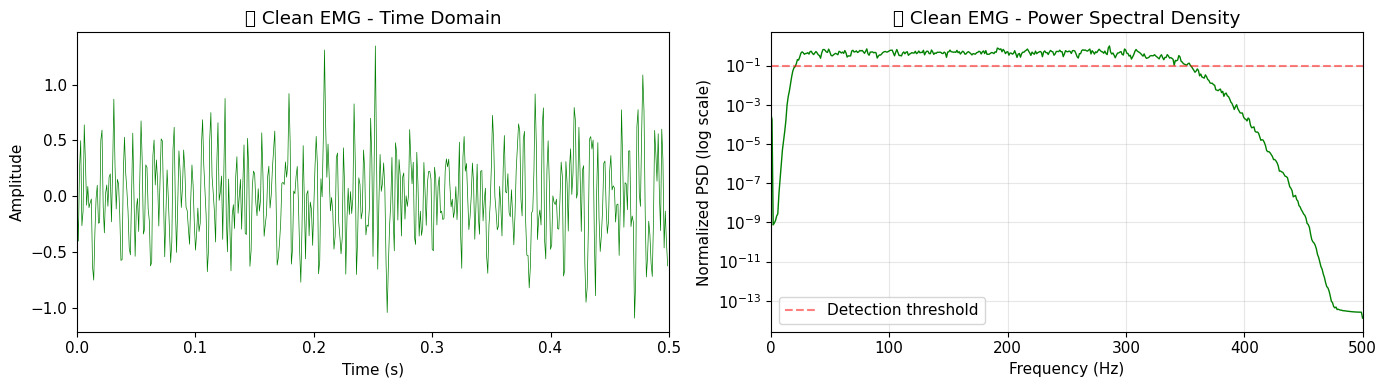

In [3]:
def plot_time_and_psd(signal, title, fs=1000, color='blue'):
    """Plot signal in time domain and frequency domain side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Time domain (first 0.5 seconds)
    t_plot = np.arange(len(signal)) / fs
    axes[0].plot(t_plot[:500], signal[:500], color=color, linewidth=0.5)
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title(f'{title} - Time Domain')
    axes[0].set_xlim(0, 0.5)
    
    # Frequency domain (PSD)
    freqs, psd = sp_signal.welch(signal, fs=fs, nperseg=1024)
    psd_norm = psd / psd.max()  # Normalize to 0-1
    
    axes[1].semilogy(freqs, psd_norm, color=color, linewidth=1)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Normalized PSD (log scale)')
    axes[1].set_title(f'{title} - Power Spectral Density')
    axes[1].set_xlim(0, 500)
    axes[1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Detection threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot clean EMG
plot_time_and_psd(clean_emg, "🟢 Clean EMG", color='green')
plt.show()

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\4211672715.py:26: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gonba\PrevOccupAI_Plus\EMG_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


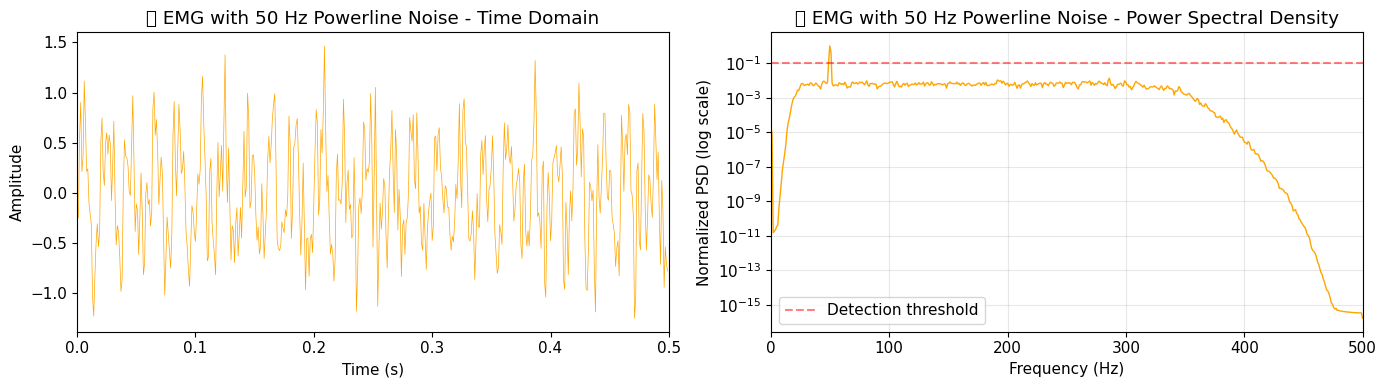

In [4]:
# Plot EMG with 50 Hz noise
plot_time_and_psd(emg_with_50hz, "🟡 EMG with 50 Hz Powerline Noise", color='orange')
plt.show()

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\4211672715.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gonba\PrevOccupAI_Plus\EMG_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


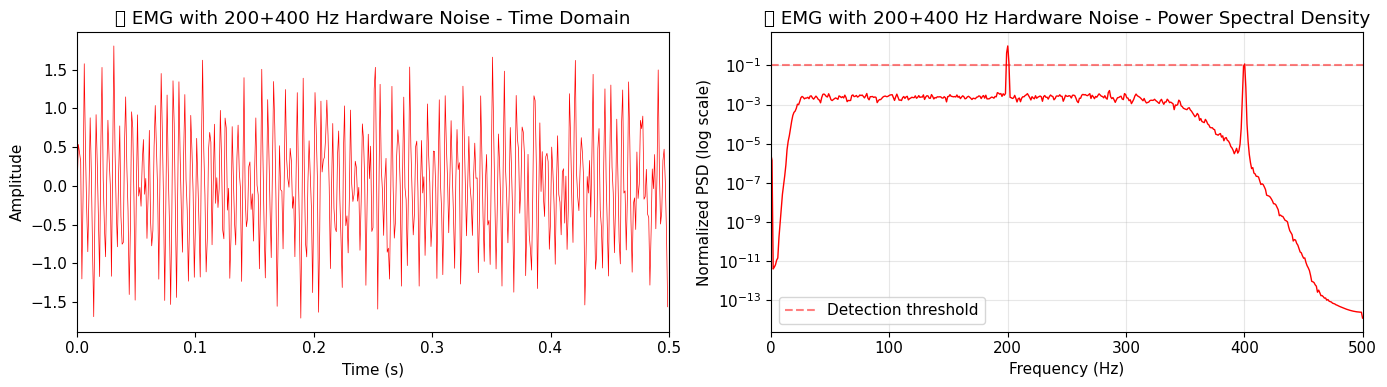

In [5]:
# Plot EMG with 200+400 Hz hardware noise
plot_time_and_psd(emg_with_hardware_noise, "🔴 EMG with 200+400 Hz Hardware Noise", color='red')
plt.show()

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\4211672715.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


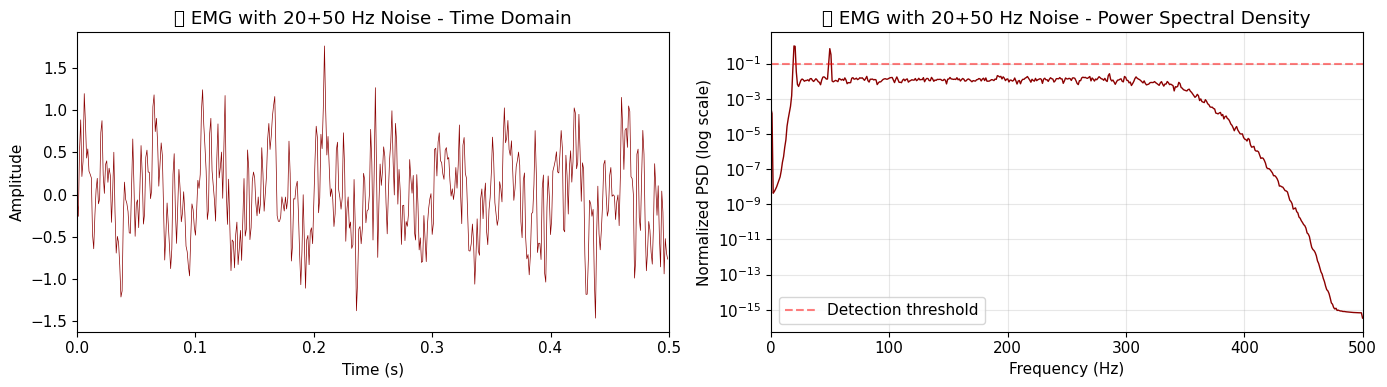

In [6]:
# Plot EMG with 20+50 Hz noise
plot_time_and_psd(emg_with_20_50hz, "🔴 EMG with 20+50 Hz Noise", color='darkred')
plt.show()

---
## Step 3: How Welch's Method Works

We use **Welch's method** to compute PSD. Here's what it does:

1. **Split signal** into overlapping segments
2. **Apply window** (Hann) to each segment to reduce spectral leakage
3. **Compute FFT** of each segment
4. **Average** all FFT results → smoother, more reliable PSD estimate

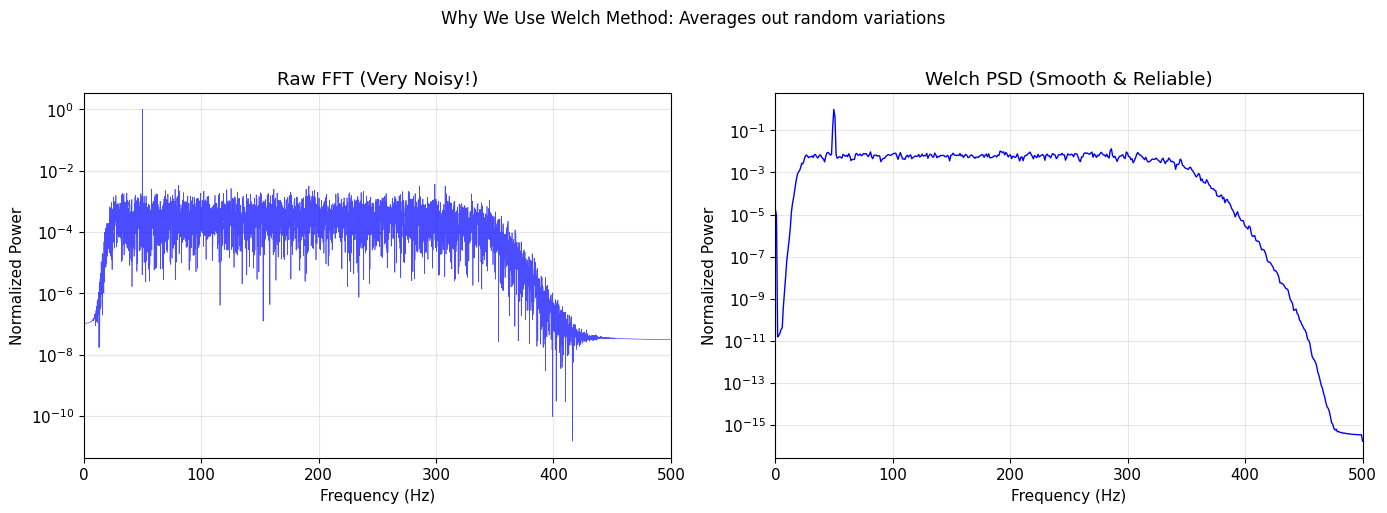

In [7]:
# Demonstrate Welch vs raw FFT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw FFT (noisy)
fft_result = np.abs(np.fft.rfft(emg_with_50hz))**2
fft_freqs = np.fft.rfftfreq(len(emg_with_50hz), 1/fs)
axes[0].semilogy(fft_freqs, fft_result/fft_result.max(), 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_title('Raw FFT (Very Noisy!)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Normalized Power')
axes[0].set_xlim(0, 500)
axes[0].grid(True, alpha=0.3)

# Welch PSD (smooth)
freqs, psd = sp_signal.welch(emg_with_50hz, fs=fs, nperseg=1024)
axes[1].semilogy(freqs, psd/psd.max(), 'b-', linewidth=1)
axes[1].set_title('Welch PSD (Smooth & Reliable)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Normalized Power')
axes[1].set_xlim(0, 500)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Why We Use Welch Method: Averages out random variations', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Our Detection Algorithm Explained

### The Pipeline:

```
EMG Signal → Welch PSD → Normalize (0-1) → Find Peaks → Check Frequencies → Decision
```

### What We Check For:

| Frequency | Cause | Decision Rule |
|-----------|-------|---------------|
| **20 Hz + 50 Hz** | Unknown (possibly electrode motion) | → **DISCARD** if both present |
| **50 Hz only** | Powerline interference | → **DISCARD** only if PSD area < 20 |
| **200 Hz + 400 Hz** | Hardware artifact | → **DISCARD** if both present |
| **200 Hz OR 400 Hz** | Might be random noise | → **WARNING** only (don't discard) |

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(psd_norm[mask_low], freqs[mask_low])
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:63: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


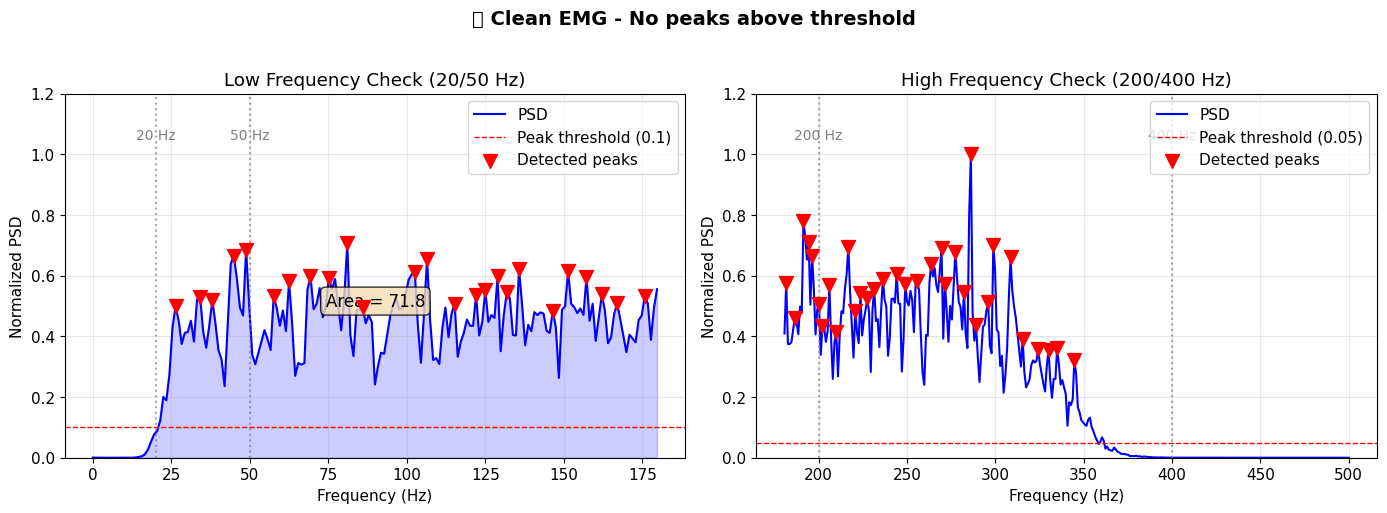

In [8]:
def visualize_detection(signal, title, fs=1000):
    """Visualize exactly what our detection algorithm sees."""
    
    # Compute PSD
    freqs, psd = sp_signal.welch(signal, fs=fs, nperseg=1024)
    psd_norm = psd / psd.max()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # LEFT: Low frequency range (0-180 Hz) - Check for 20/50 Hz
    mask_low = freqs <= 180
    axes[0].plot(freqs[mask_low], psd_norm[mask_low], 'b-', linewidth=1.5, label='PSD')
    axes[0].axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='Peak threshold (0.1)')
    
    # Mark target frequencies
    for target, name in [(20, '20 Hz'), (50, '50 Hz')]:
        axes[0].axvline(x=target, color='gray', linestyle=':', alpha=0.7)
        axes[0].text(target, 1.05, name, ha='center', fontsize=10, color='gray')
    
    # Find and mark peaks
    peaks, props = sp_signal.find_peaks(psd_norm[mask_low], prominence=0.1)
    peak_freqs = freqs[mask_low][peaks]
    peak_vals = psd_norm[mask_low][peaks]
    axes[0].scatter(peak_freqs, peak_vals, color='red', s=100, zorder=5, marker='v', label='Detected peaks')
    
    # Calculate area under curve
    area = np.trapz(psd_norm[mask_low], freqs[mask_low])
    axes[0].fill_between(freqs[mask_low], psd_norm[mask_low], alpha=0.2, color='blue')
    axes[0].text(90, 0.5, f'Area = {area:.1f}', fontsize=12, ha='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Normalized PSD')
    axes[0].set_title('Low Frequency Check (20/50 Hz)')
    axes[0].legend(loc='upper right')
    axes[0].set_ylim(0, 1.2)
    axes[0].grid(True, alpha=0.3)
    
    # RIGHT: High frequency range (>180 Hz) - Check for 200/400 Hz
    mask_high = freqs > 180
    axes[1].plot(freqs[mask_high], psd_norm[mask_high], 'b-', linewidth=1.5, label='PSD')
    axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1, label='Peak threshold (0.05)')
    
    # Mark target frequencies
    for target, name in [(200, '200 Hz'), (400, '400 Hz')]:
        axes[1].axvline(x=target, color='gray', linestyle=':', alpha=0.7)
        axes[1].text(target, 1.05, name, ha='center', fontsize=10, color='gray')
    
    # Find and mark peaks
    peaks_high, _ = sp_signal.find_peaks(psd_norm[mask_high], prominence=0.05)
    peak_freqs_high = freqs[mask_high][peaks_high]
    peak_vals_high = psd_norm[mask_high][peaks_high]
    axes[1].scatter(peak_freqs_high, peak_vals_high, color='red', s=100, zorder=5, marker='v', label='Detected peaks')
    
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Normalized PSD')
    axes[1].set_title('High Frequency Check (200/400 Hz)')
    axes[1].legend(loc='upper right')
    axes[1].set_ylim(0, 1.2)
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

# Clean EMG
visualize_detection(clean_emg, "🟢 Clean EMG - No peaks above threshold")
plt.show()

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(psd_norm[mask_low], freqs[mask_low])
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:63: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


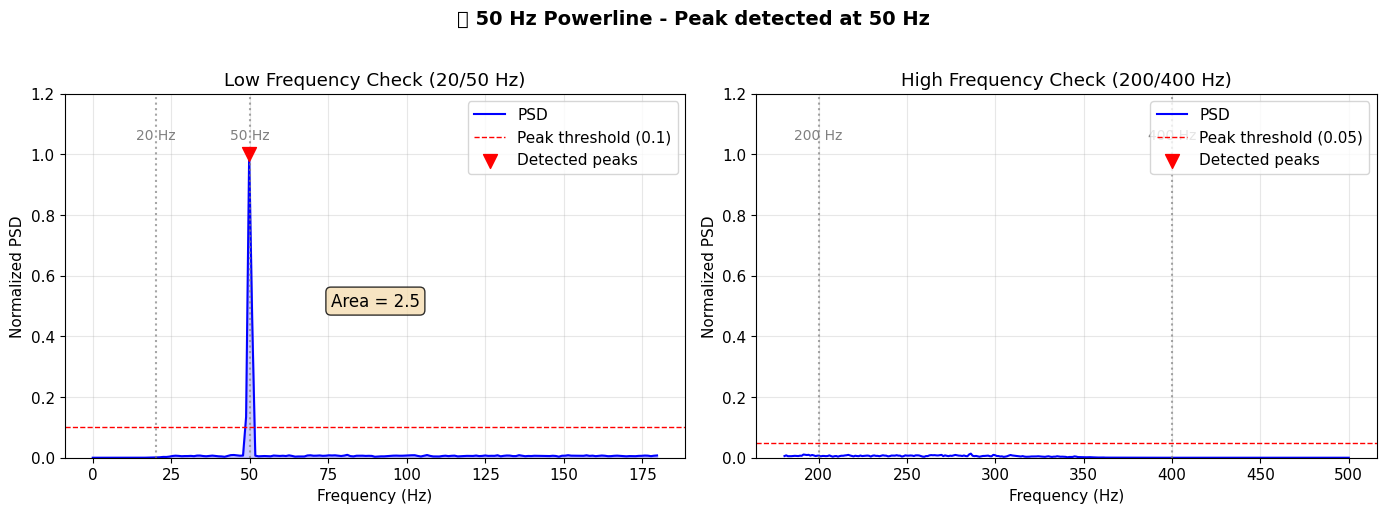

In [9]:
# 50 Hz noise
visualize_detection(emg_with_50hz, "🟡 50 Hz Powerline - Peak detected at 50 Hz")
plt.show()

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(psd_norm[mask_low], freqs[mask_low])
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


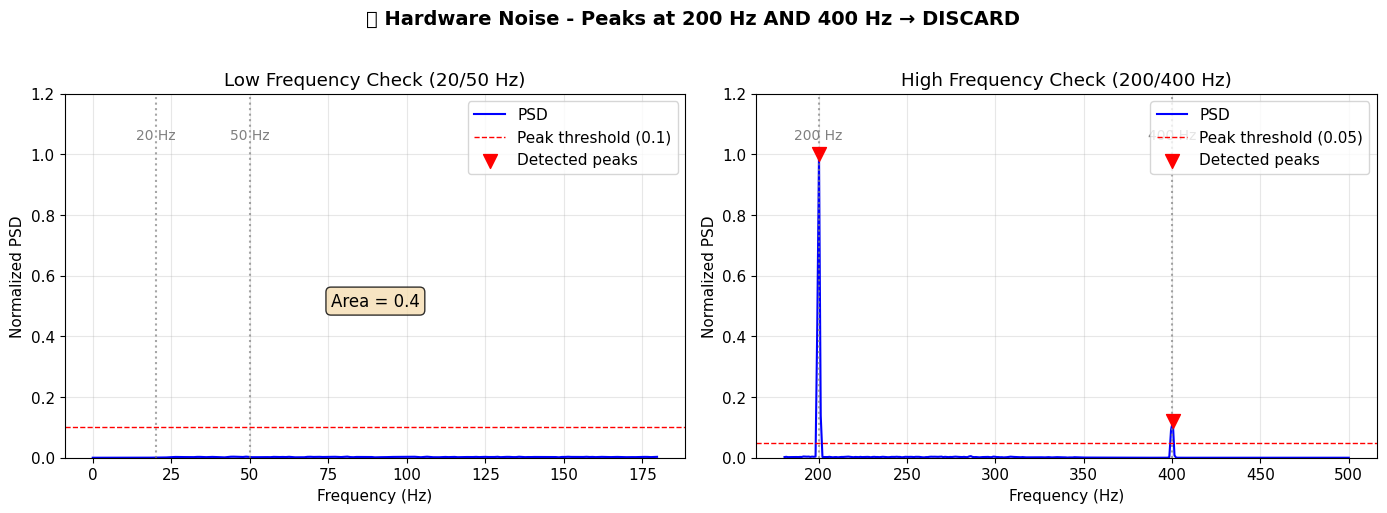

In [10]:
# 200+400 Hz hardware noise
visualize_detection(emg_with_hardware_noise, "🔴 Hardware Noise - Peaks at 200 Hz AND 400 Hz → DISCARD")
plt.show()

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(psd_norm[mask_low], freqs[mask_low])
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\1339181436.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


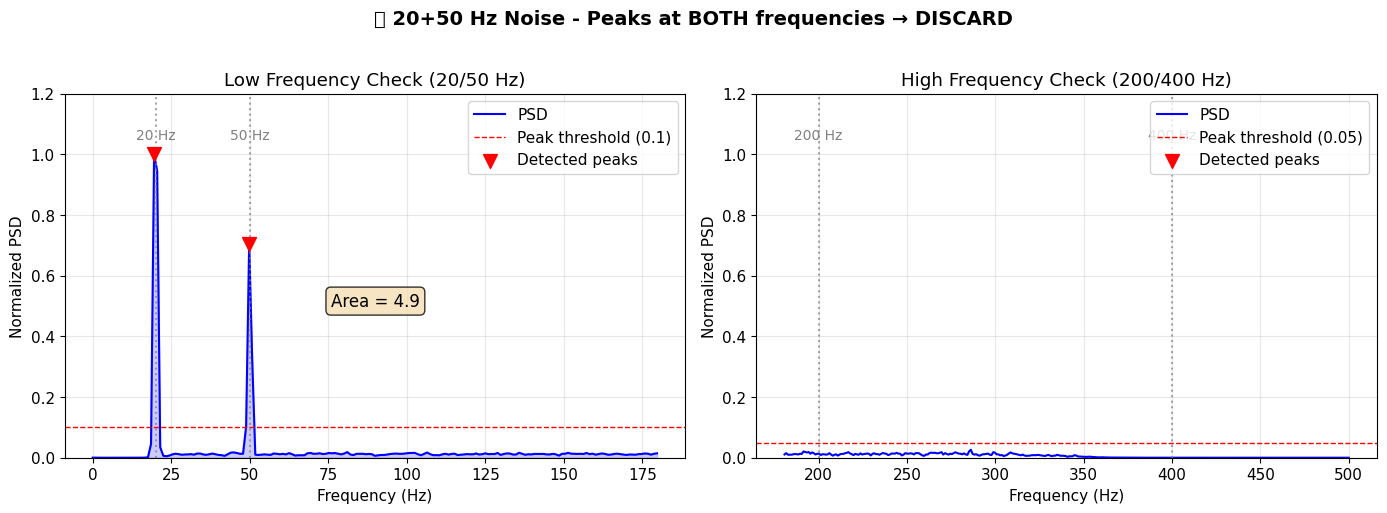

In [11]:
# 20+50 Hz noise
visualize_detection(emg_with_20_50hz, "🔴 20+50 Hz Noise - Peaks at BOTH frequencies → DISCARD")
plt.show()

---
## Step 5: Real Data - Subject 81 (Known Hardware Noise)

Let's look at actual data where we detected the 200+400 Hz hardware noise.

In [18]:
# Skip real data loading - requires running from project root directory
# The synthetic examples above demonstrate the concept perfectly

print("Skipping real data load")
print("Run this notebook from project root to load subject 81 real data")
print("For now, the synthetic examples above show exactly what real 200+400 Hz noise looks like")

Skipping real data load
Run this notebook from project root to load subject 81 real data
For now, the synthetic examples above show exactly what real 200+400 Hz noise looks like


In [22]:
# Compare clean vs noisy real data
if 'emg_left_filt' in dir():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Clean (LEFT)
    freqs_left, psd_left = sp_signal.welch(emg_left_filt, fs=fs, nperseg=4096)
    psd_left_norm = psd_left / psd_left.max()
    
    axes[0,0].plot(np.arange(5000)/fs, emg_left_filt[:5000], 'g-', linewidth=0.3)
    axes[0,0].set_title('🟢 LEFT Side (Clean) - Time Domain')
    axes[0,0].set_xlabel('Time (s)')
    axes[0,0].set_ylabel('mV')
    
    axes[0,1].semilogy(freqs_left, psd_left_norm, 'g-', linewidth=1)
    axes[0,1].axvline(x=200, color='red', linestyle='--', alpha=0.5, label='200 Hz')
    axes[0,1].axvline(x=400, color='red', linestyle='--', alpha=0.5, label='400 Hz')
    axes[0,1].set_title('🟢 LEFT Side (Clean) - PSD')
    axes[0,1].set_xlabel('Frequency (Hz)')
    axes[0,1].set_ylabel('Normalized PSD')
    axes[0,1].set_xlim(0, 500)
    axes[0,1].legend()
    
    # Noisy (RIGHT)
    freqs_right, psd_right = sp_signal.welch(emg_right_filt, fs=fs, nperseg=4096)
    psd_right_norm = psd_right / psd_right.max()
    
    axes[1,0].plot(np.arange(5000)/fs, emg_right_filt[:5000], 'r-', linewidth=0.3)
    axes[1,0].set_title('🔴 RIGHT Side (Hardware Noise) - Time Domain')
    axes[1,0].set_xlabel('Time (s)')
    axes[1,0].set_ylabel('mV')
    
    axes[1,1].semilogy(freqs_right, psd_right_norm, 'r-', linewidth=1)
    axes[1,1].axvline(x=200, color='red', linestyle='--', alpha=0.5, label='200 Hz')
    axes[1,1].axvline(x=400, color='red', linestyle='--', alpha=0.5, label='400 Hz')
    axes[1,1].set_title('🔴 RIGHT Side (Hardware Noise) - PSD')
    axes[1,1].set_xlabel('Frequency (Hz)')
    axes[1,1].set_ylabel('Normalized PSD')
    axes[1,1].set_xlim(0, 500)
    axes[1,1].legend()
    
    # Print actual values at target frequencies
    idx_200 = np.argmin(np.abs(freqs_right - 200))
    idx_400 = np.argmin(np.abs(freqs_right - 400))
    
    plt.suptitle('Subject 81: Real Hardware Noise Detection', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    print(f"\n📊 Normalized PSD at target frequencies:")
    print(f"   LEFT (clean):  200 Hz = {psd_left_norm[idx_200]:.3f}, 400 Hz = {psd_left_norm[idx_400]:.3f}")
    print(f"   RIGHT (noisy): 200 Hz = {psd_right_norm[idx_200]:.3f}, 400 Hz = {psd_right_norm[idx_400]:.3f}")
    print(f"\n   ⚠️ RIGHT side has 200 Hz = {psd_right_norm[idx_200]*100:.0f}% of max power!")
    
    plt.show()

---
## Step 6: Why Normalized PSD?

We normalize PSD to range 0-1 because:

1. **Different subjects have different signal amplitudes** (muscle mass, skin thickness, electrode placement)
2. **We care about relative power**, not absolute power
3. **Thresholds work consistently** across all recordings

```python
psd_norm = psd / psd.max()  # Max value becomes 1.0
```

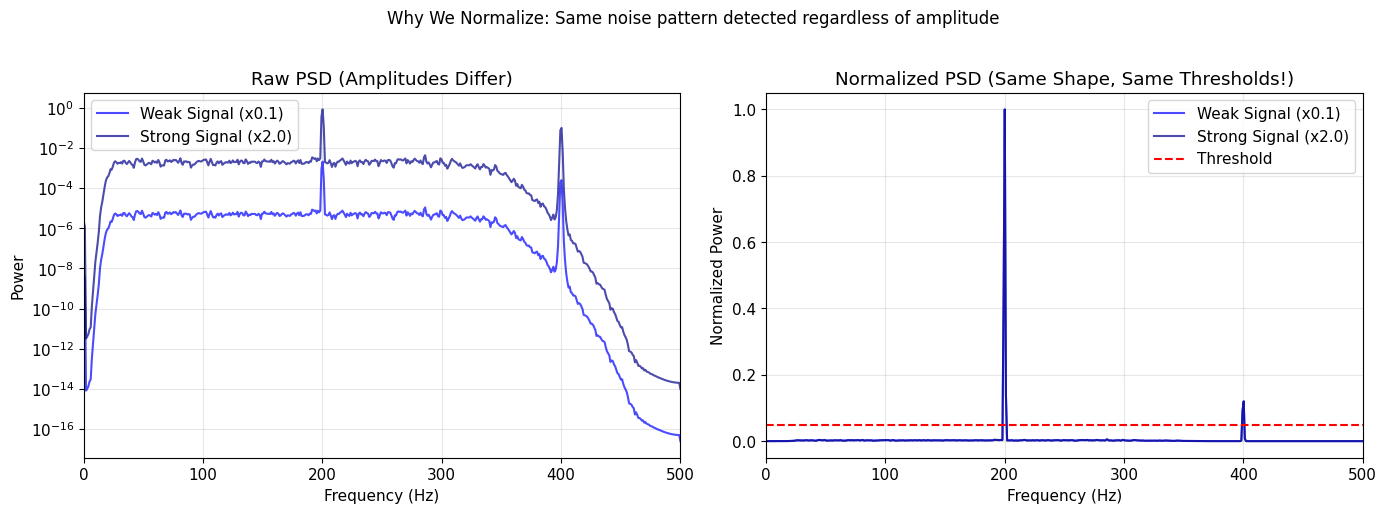

In [19]:
# Demonstrate normalization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create two signals with different amplitudes but same noise pattern
weak_signal = emg_with_hardware_noise * 0.1
strong_signal = emg_with_hardware_noise * 2.0

for i, (sig, name, color) in enumerate([(weak_signal, 'Weak Signal (x0.1)', 'blue'),
                                         (strong_signal, 'Strong Signal (x2.0)', 'darkblue')]):
    freqs, psd = sp_signal.welch(sig, fs=fs, nperseg=1024)
    
    # Raw PSD
    axes[0].semilogy(freqs, psd, color=color, linewidth=1.5, label=name, alpha=0.7)
    
    # Normalized PSD
    axes[1].plot(freqs, psd/psd.max(), color=color, linewidth=1.5, label=name, alpha=0.7)

axes[0].set_title('Raw PSD (Amplitudes Differ)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power')
axes[0].set_xlim(0, 500)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Normalized PSD (Same Shape, Same Thresholds!)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Normalized Power')
axes[1].set_xlim(0, 500)
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Why We Normalize: Same noise pattern detected regardless of amplitude', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7: The "Area Under PSD" Metric

We also compute the **area under the PSD curve (0-180 Hz)** to assess signal quality:

| Area | Interpretation |
|------|----------------|
| **< 20** | Very poor signal - almost no EMG content |
| **20-45** | Low signal quality |
| **45-115** | Normal EMG signal |
| **> 115** | Unusual concentration of power |

This helps distinguish:
- **50 Hz noise + good EMG** → Keep (noise is minor)
- **50 Hz noise + no EMG** → Discard (electrode lost contact)

C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\441898863.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_good = np.trapz(psd_norm[mask], freqs[mask])
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\441898863.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_bad = np.trapz(psd2_norm[mask2], freqs2[mask2])
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\441898863.py:38: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gonba\AppData\Local\Temp\ipykernel_73812\441898863.py:38: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gonba\PrevOccupAI_Plus\EMG_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) m

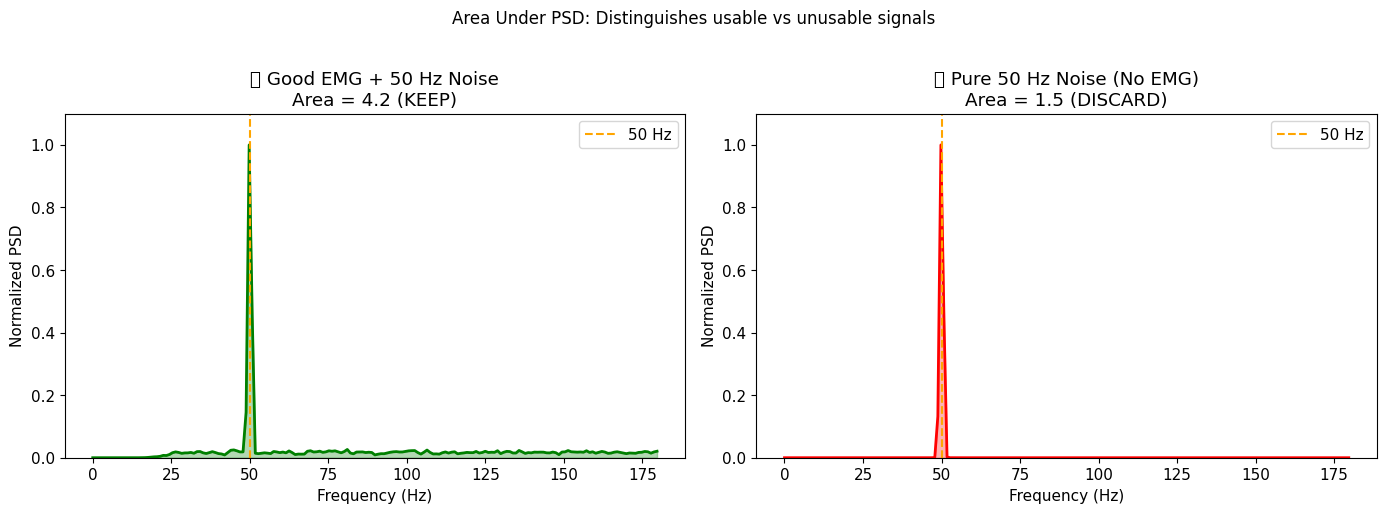


📊 Area comparison:
   Good EMG + 50 Hz: Area = 4.2 → Above threshold, KEEP
   Pure 50 Hz noise: Area = 1.5 → Below 20, DISCARD


In [20]:
def show_area_comparison():
    """Show how area distinguishes good vs bad signals with 50 Hz noise."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Good EMG + 50 Hz
    good_emg = clean_emg + 0.3 * np.sin(2 * np.pi * 50 * t)
    freqs, psd = sp_signal.welch(good_emg, fs=fs, nperseg=1024)
    psd_norm = psd / psd.max()
    mask = freqs <= 180
    area_good = np.trapz(psd_norm[mask], freqs[mask])
    
    axes[0].fill_between(freqs[mask], psd_norm[mask], alpha=0.3, color='green')
    axes[0].plot(freqs[mask], psd_norm[mask], 'g-', linewidth=2)
    axes[0].axvline(x=50, color='orange', linestyle='--', label='50 Hz')
    axes[0].set_title(f'🟢 Good EMG + 50 Hz Noise\nArea = {area_good:.1f} (KEEP)')
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Normalized PSD')
    axes[0].set_ylim(0, 1.1)
    axes[0].legend()
    
    # Pure 50 Hz (no EMG)
    pure_noise = 0.5 * np.sin(2 * np.pi * 50 * t) + np.random.randn(len(t)) * 0.02
    freqs2, psd2 = sp_signal.welch(pure_noise, fs=fs, nperseg=1024)
    psd2_norm = psd2 / psd2.max()
    mask2 = freqs2 <= 180
    area_bad = np.trapz(psd2_norm[mask2], freqs2[mask2])
    
    axes[1].fill_between(freqs2[mask2], psd2_norm[mask2], alpha=0.3, color='red')
    axes[1].plot(freqs2[mask2], psd2_norm[mask2], 'r-', linewidth=2)
    axes[1].axvline(x=50, color='orange', linestyle='--', label='50 Hz')
    axes[1].set_title(f'🔴 Pure 50 Hz Noise (No EMG)\nArea = {area_bad:.1f} (DISCARD)')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Normalized PSD')
    axes[1].set_ylim(0, 1.1)
    axes[1].legend()
    
    plt.suptitle('Area Under PSD: Distinguishes usable vs unusable signals', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Area comparison:")
    print(f"   Good EMG + 50 Hz: Area = {area_good:.1f} → Above threshold, KEEP")
    print(f"   Pure 50 Hz noise: Area = {area_bad:.1f} → Below {20}, DISCARD")

show_area_comparison()

---
## Summary: Our Detection Logic

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         PSD NOISE DETECTION FLOW                            │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  EMG Signal                                                                 │
│      │                                                                      │
│      ▼                                                                      │
│  ┌───────────────────┐                                                      │
│  │ Welch PSD (1024)  │  → Compute power at each frequency                   │
│  └─────────┬─────────┘                                                      │
│            │                                                                │
│            ▼                                                                │
│  ┌───────────────────┐                                                      │
│  │ Normalize (0-1)   │  → Max power = 1.0                                   │
│  └─────────┬─────────┘                                                      │
│            │                                                                │
│            ├──────────────────────────────────────┐                         │
│            │                                      │                         │
│            ▼                                      ▼                         │
│  ┌─────────────────────┐              ┌─────────────────────┐               │
│  │ CHECK 0-180 Hz     │              │ CHECK >180 Hz       │               │
│  │ (20/50 Hz noise)   │              │ (200/400 Hz noise)  │               │
│  └─────────┬──────────┘              └─────────┬───────────┘               │
│            │                                   │                            │
│            ▼                                   ▼                            │
│  ┌─────────────────────┐              ┌─────────────────────┐               │
│  │ Find peaks > 0.1   │              │ Find peaks > 0.05   │               │
│  │ prominence         │              │ prominence          │               │
│  └─────────┬──────────┘              └─────────┬───────────┘               │
│            │                                   │                            │
│            ▼                                   ▼                            │
│   ┌────────────────┐                  ┌────────────────┐                    │
│   │ 20 + 50 Hz?   │─── YES ──→       │ 200 + 400 Hz? │─── YES ──→ 🔴      │
│   │ both peaks     │           🔴     │ both peaks     │          DISCARD   │
│   └───────┬────────┘         DISCARD  └───────┬────────┘                    │
│           │ NO                                │ NO                          │
│           ▼                                   ▼                             │
│   ┌────────────────┐                  ┌────────────────┐                    │
│   │ 50 Hz only +   │                  │ Single peak +  │                    │
│   │ Area < 20?     │─── YES ──→ 🔴    │ Area anomaly?  │─── YES ──→ ⚠️     │
│   └───────┬────────┘         DISCARD  └───────┬────────┘          WARNING   │
│           │ NO                                │ NO                          │
│           ▼                                   ▼                             │
│          🟢 KEEP                             🟢 KEEP                        │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

In [21]:
# Run our actual detection function on all examples
from sensors.load.emg_quality import detect_psd_noise

test_signals = [
    (clean_emg, "Clean EMG"),
    (emg_with_50hz, "EMG + 50 Hz"),
    (emg_with_hardware_noise, "EMG + 200/400 Hz"),
    (emg_with_20_50hz, "EMG + 20/50 Hz"),
]

print("\n" + "="*70)
print("RUNNING ACTUAL DETECTION ON TEST SIGNALS")
print("="*70)

for signal, name in test_signals:
    is_noisy, issues = detect_psd_noise(signal, fs=1000)
    status = "🔴 NOISY" if is_noisy else "🟢 CLEAN"
    print(f"\n{name}:")
    print(f"   Result: {status}")
    if issues:
        for issue in issues:
            print(f"   Issue: {issue['message']}")


RUNNING ACTUAL DETECTION ON TEST SIGNALS

Clean EMG:
   Result: 🟢 CLEAN

EMG + 50 Hz:
   Result: 🔴 NOISY
   Issue: 50 Hz powerline noise with low signal content (area=2.5 < 20.0)

EMG + 200/400 Hz:
   Result: 🔴 NOISY
   Issue: 200 Hz and 400 Hz hardware noise detected (area=0.4)

EMG + 20/50 Hz:
   Result: 🔴 NOISY
   Issue: 20 Hz and 50 Hz noise peaks detected (signal not recoverable)


---
## Key Takeaways

1. **PSD reveals noise invisible in time domain** - Periodic interference shows as sharp spikes

2. **We use Welch's method** - Averages multiple FFTs for smooth, reliable estimates

3. **Normalization is crucial** - Same thresholds work for all signal amplitudes

4. **Two frequency regions checked separately**:
   - Low (0-180 Hz): 20/50 Hz electrode/powerline issues
   - High (>180 Hz): 200/400 Hz hardware artifacts

5. **Conservative detection rules**:
   - Require BOTH frequencies for hardware noise (200+400 Hz)
   - Consider PSD area when 50 Hz detected
   - Single peaks only generate warnings, not rejections

6. **Validated on real data**:
   - Subject 81 RIGHT: True hardware noise (90% power at 200 Hz)
   - Subject 109: 30 clean sessions, 0 false positives